Import packages

In [14]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import sklearn
import altair as alt
alt.data_transformers.enable("vegafusion")
import seaborn as sns
import numpy as np

from sklearn.pipeline import Pipeline, make_pipeline

Import aggregated parquet file

In [15]:
df = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Supermarket/Code/data/raw/history_aggregated.parquet', engine='pyarrow')

In [16]:
df.head()

,onpromotion,item_nbr,week,date,unit_sales_sum,count,family,class,perishable
0,False,764438,201323,2013-06-04 00:00:00+00:00,1925.0,180,GROCERY I,1072,0
1,False,764438,201324,2013-06-11 00:00:00+00:00,1516.0,164,GROCERY I,1072,0
2,False,764438,201325,2013-06-18 00:00:00+00:00,1656.0,176,GROCERY I,1072,0
3,False,764438,201326,2013-06-25 00:00:00+00:00,1610.0,177,GROCERY I,1072,0
4,False,764438,201327,2013-07-02 00:00:00+00:00,1987.0,182,GROCERY I,1072,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948220 entries, 0 to 948219
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   onpromotion     948220 non-null  bool               
 1   item_nbr        948220 non-null  int64              
 2   week            948220 non-null  int64              
 3   date            948220 non-null  datetime64[us, UTC]
 4   unit_sales_sum  948220 non-null  float64            
 5   count           948220 non-null  int64              
 6   family          948220 non-null  category           
 7   class           948220 non-null  int64              
 8   perishable      948220 non-null  int64              
dtypes: bool(1), category(1), datetime64[us, UTC](1), float64(1), int64(5)
memory usage: 52.5 MB


Transform week into date (Tuesday)

In [18]:
# Extract year and week number from 'week' column
df['year'] = df['week'] // 100
df['week_number'] = df['week'] % 100

# Convert year-week to datetime (Monday of the week)
df['week_date'] = pd.to_datetime(df['year'].astype(str) + df['week_number'].astype(str) + '1', format='%G%V%u')
df['week_to_date_tuesday'] = df['week_date'] + pd.Timedelta(days=1)
df['week_to_date_wednesday'] = df['week_date'] + pd.Timedelta(days=2)
df['week_to_date_thursday'] = df['week_date'] + pd.Timedelta(days=3)
df['week_to_date_saturday'] = df['week_date'] + pd.Timedelta(days=-2)
df['week_to_date_sunday'] = df['week_date'] + pd.Timedelta(days=-1)
df['week_to_date_monday'] = df['week_date'] + pd.Timedelta(days=7)
df['week_to_date_tuesday2'] = df['week_date'] + pd.Timedelta(days=8)

# Drop columns
df.drop(columns=['year', 'week_number'], inplace=True)

df.head()

,onpromotion,item_nbr,week,date,unit_sales_sum,count,family,class,perishable,week_date,week_to_date_tuesday,week_to_date_wednesday,week_to_date_thursday,week_to_date_saturday,week_to_date_sunday,week_to_date_monday,week_to_date_tuesday2
0,False,764438,201323,2013-06-04 00:00:00+00:00,1925.0,180,GROCERY I,1072,0,2013-06-03,2013-06-04,2013-06-05,2013-06-06,2013-06-01,2013-06-02,2013-06-10,2013-06-11
1,False,764438,201324,2013-06-11 00:00:00+00:00,1516.0,164,GROCERY I,1072,0,2013-06-10,2013-06-11,2013-06-12,2013-06-13,2013-06-08,2013-06-09,2013-06-17,2013-06-18
2,False,764438,201325,2013-06-18 00:00:00+00:00,1656.0,176,GROCERY I,1072,0,2013-06-17,2013-06-18,2013-06-19,2013-06-20,2013-06-15,2013-06-16,2013-06-24,2013-06-25
3,False,764438,201326,2013-06-25 00:00:00+00:00,1610.0,177,GROCERY I,1072,0,2013-06-24,2013-06-25,2013-06-26,2013-06-27,2013-06-22,2013-06-23,2013-07-01,2013-07-02
4,False,764438,201327,2013-07-02 00:00:00+00:00,1987.0,182,GROCERY I,1072,0,2013-07-01,2013-07-02,2013-07-03,2013-07-04,2013-06-29,2013-06-30,2013-07-08,2013-07-09


Downcast dataframe

In [19]:
date_columns = [
    'date', 'week_date', 'week_to_date_tuesday', 'week_to_date_wednesday',
    'week_to_date_thursday', 'week_to_date_saturday', 'week_to_date_sunday',
    'week_to_date_monday', 'week_to_date_tuesday2'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col].dt.date)

# +1 year in column 'date', for 'week' starting with 2016 or 2017
df.loc[df['week'].astype(str).str.startswith(('2016', '2017')), 'date'] += pd.DateOffset(years=1)

df['comparison'] = (df['date'] == df['week_to_date_tuesday']) | (df['date'] == df['week_to_date_wednesday']) | (df['date'] == df['week_to_date_thursday']) | (df['date'] == df['week_to_date_sunday']) | (df['date'] == df['week_to_date_saturday'])| (df['date'] == df['week_to_date_tuesday2']) | (df['date'] == df['week_to_date_sunday']) | (df['date'] == df['week_to_date_saturday'])| (df['date'] == df['week_to_date_monday'])

for old, new in zip(['integer', 'float'], ['unsigned', 'float']):

    for col in df.select_dtypes(include=old).columns:
        
        df[col] = pd.to_numeric(df[col], downcast=new)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948220 entries, 0 to 948219
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   onpromotion             948220 non-null  bool          
 1   item_nbr                948220 non-null  uint32        
 2   week                    948220 non-null  uint32        
 3   date                    948220 non-null  datetime64[ns]
 4   unit_sales_sum          948220 non-null  float64       
 5   count                   948220 non-null  uint16        
 6   family                  948220 non-null  category      
 7   class                   948220 non-null  uint16        
 8   perishable              948220 non-null  uint8         
 9   week_date               948220 non-null  datetime64[ns]
 10  week_to_date_tuesday    948220 non-null  datetime64[ns]
 11  week_to_date_wednesday  948220 non-null  datetime64[ns]
 12  week_to_date_thursday   948220

,onpromotion,item_nbr,week,date,unit_sales_sum,count,family,class,perishable,week_date,week_to_date_tuesday,week_to_date_wednesday,week_to_date_thursday,week_to_date_saturday,week_to_date_sunday,week_to_date_monday,week_to_date_tuesday2,comparison
0,False,764438,201323,2013-06-04,1925.0,180,GROCERY I,1072,0,2013-06-03,2013-06-04,2013-06-05,2013-06-06,2013-06-01,2013-06-02,2013-06-10,2013-06-11,True
1,False,764438,201324,2013-06-11,1516.0,164,GROCERY I,1072,0,2013-06-10,2013-06-11,2013-06-12,2013-06-13,2013-06-08,2013-06-09,2013-06-17,2013-06-18,True
2,False,764438,201325,2013-06-18,1656.0,176,GROCERY I,1072,0,2013-06-17,2013-06-18,2013-06-19,2013-06-20,2013-06-15,2013-06-16,2013-06-24,2013-06-25,True
3,False,764438,201326,2013-06-25,1610.0,177,GROCERY I,1072,0,2013-06-24,2013-06-25,2013-06-26,2013-06-27,2013-06-22,2013-06-23,2013-07-01,2013-07-02,True
4,False,764438,201327,2013-07-02,1987.0,182,GROCERY I,1072,0,2013-07-01,2013-07-02,2013-07-03,2013-07-04,2013-06-29,2013-06-30,2013-07-08,2013-07-09,True


Scatterplot between 'date' and 'week_date'

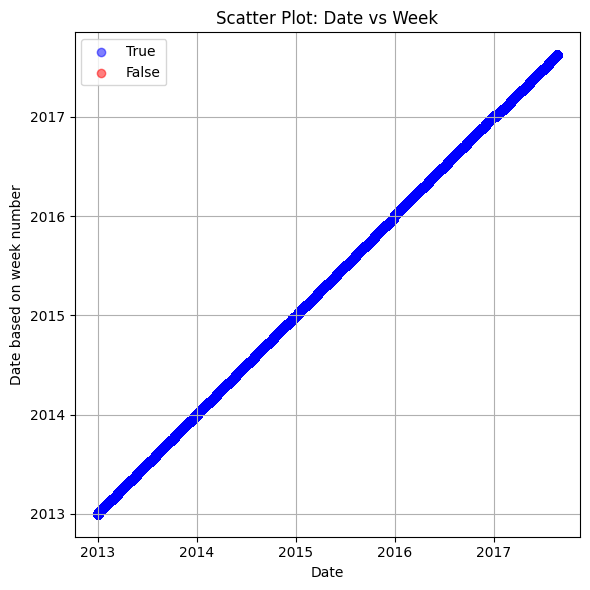

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(df[df['comparison']]['date'], df[df['comparison']]['week_to_date_tuesday'], color='blue', alpha=0.5, label='True')
plt.scatter(df[~df['comparison']]['date'], df[~df['comparison']]['week_to_date_tuesday'], color='red', alpha=0.5, label='False')
plt.xlabel('Date')
plt.ylabel('Date based on week number')
plt.title('Scatter Plot: Date vs Week')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Corrected the dates in the date column, so now al other dates can be dropped

In [21]:
df.drop(columns=['week', 'week_to_date_tuesday', 'week_to_date_wednesday', 'week_to_date_thursday', 'comparison', 'week_date', 'week_to_date_saturday', 'week_to_date_sunday', 'week_to_date_monday', 'week_to_date_tuesday2'], inplace=True)
df.head(20)


,onpromotion,item_nbr,date,unit_sales_sum,count,family,class,perishable
0,False,764438,2013-06-04,1925.0,180,GROCERY I,1072,0
1,False,764438,2013-06-11,1516.0,164,GROCERY I,1072,0
2,False,764438,2013-06-18,1656.0,176,GROCERY I,1072,0
3,False,764438,2013-06-25,1610.0,177,GROCERY I,1072,0
4,False,764438,2013-07-02,1987.0,182,GROCERY I,1072,0
5,False,764438,2013-07-09,1588.0,169,GROCERY I,1072,0
6,False,764438,2013-07-16,1688.0,171,GROCERY I,1072,0
7,False,764438,2013-07-23,1572.0,165,GROCERY I,1072,0
8,False,764438,2013-07-30,1755.0,176,GROCERY I,1072,0
9,False,764438,2013-08-06,1780.0,178,GROCERY I,1072,0


In [22]:
specific_item_nbr = 764438
count_specific_item_nbr = (df['item_nbr'] == specific_item_nbr).sum()

print(f"Occurrences of item_nbr {specific_item_nbr}: {count_specific_item_nbr}")

Occurrences of item_nbr 764438: 306


Selection of dataframes

In [23]:
df_all = df

# Find the most recent and most historical dates
date_max = df['date'].max()
date_min = df['date'].min()

# Display the results
print(f"Most recent date: {date_max}")
print(f"Most historical date: {date_min}")

# Select last year
date_last_year = date_max - pd.Timedelta(days=365)
df_recent_year = df[df['date'] >= date_last_year]
df_recent_year.head()

df_2017 = df[df['date'].dt.year == 2017]
df_2016 = df[df['date'].dt.year == 2016]
df_2015 = df[df['date'].dt.year == 2015]
df_2014 = df[df['date'].dt.year == 2014]
df_2013 = df[df['date'].dt.year == 2013]

# Choose which dataframe you will use below
#df_chart = df_recent_year
df_chart = df_all
#df_chart = df_2013
#df_chart = df_2014
#df_chart = df_2015
#df_chart = df_2016
#df_chart = df_2017

Most recent date: 2017-08-21 00:00:00
Most historical date: 2013-01-01 00:00:00


Linediagram Sales for each item

In [24]:
chart = alt.Chart(df_chart).mark_line(opacity=0.3).encode(
    x='date:T',
    y='unit_sales_sum:Q',
    color='item_nbr:N'
).properties(
    title='Sum of Unit Sales Over Time for Each Item',
    width=800,
    height=400
)

chart

In [ ]:
df_negative_sales = df_chart[df_chart['unit_sales_sum'] < 0]

df_negative_sales

Linediagram Sales, by promotion

In [ ]:
df_aggregated = df_chart.groupby(['item_nbr', 'onpromotion', 'date'], as_index=False)['unit_sales_sum'].sum()

hist = alt.Chart(df_aggregated).mark_bar().encode(
    alt.X('item_nbr:N', title='item', sort=alt.EncodingSortField(field='unit_sales_sum', op='sum', order='descending')),
    alt.Y('unit_sales_sum:Q', title='Sum of unit sales'),
    color=alt.Color('onpromotion:N')
).properties(
    title='Histogram Sum of unit sales, promotion',
    width=1600,
    height=400
)

hist.display()

Linediagram Sales, perishable yes/no

In [ ]:
df_aggregated = df_chart.groupby(['date', 'perishable'], as_index=False)['unit_sales_sum'].sum()

chart = alt.Chart(df_aggregated).mark_line(opacity=0.8).encode(
    x='date:T',
    y='unit_sales_sum:Q',
    color=alt.Color('perishable:N')
).properties(
    title='Total Sum of Unit Sales Over Time by Perishability',
    width=800,
    height=400
)

chart

Linediagram Sales per family

In [ ]:
# Aggregate the data by date and perishability
df_aggregated = df_chart.groupby(['date', 'family'], as_index=False)['unit_sales_sum'].sum()

# Create the line chart with aggregated data
chart = alt.Chart(df_aggregated).mark_line(opacity=0.8).encode(
    x='date:T',
    y='unit_sales_sum:Q',
    color=alt.Color('family:N')
).properties(
    title='Total Sum of Unit Sales Over Time by Family',
    width=800,
    height=400
)

chart

Distribution of family and classes

In [ ]:
df_aggregated = df_chart.groupby(['family', 'class'], as_index=False)['unit_sales_sum'].sum()

hist = alt.Chart(df_aggregated).mark_bar().encode(
    alt.X('family:N', title='Family', sort=alt.EncodingSortField(field='unit_sales_sum', op='sum', order='descending')),
    alt.Y('unit_sales_sum:Q', title='Sum of Unit Sales'),
    color=alt.Color('class:N')
).properties(
    title='Histogram of Sum of Unit Sales by Family, colored by class',
    width=600,
    height=400
)

hist.display()

df_aggregated = df_chart.groupby(['family', 'perishable'], as_index=False)['unit_sales_sum'].sum()

hist = alt.Chart(df_aggregated).mark_bar().encode(
    alt.X('family:N', title='Family', sort=alt.EncodingSortField(field='unit_sales_sum', op='sum', order='descending')),
    alt.Y('unit_sales_sum:Q', title='Sum of Unit Sales'),
    color=alt.Color('perishable:N')
).properties(
    title='Histogram of Sum of Unit Sales by Family, colored by perishability',
    width=600,
    height=400
)

hist.display()


In [ ]:
df_aggregated = df_chart.groupby('family', as_index=False)['unit_sales_sum'].sum()

total_sales = df_aggregated['unit_sales_sum'].sum()
df_aggregated['percentage'] = df_aggregated['unit_sales_sum'] / total_sales * 100

chart = alt.Chart(df_aggregated).mark_arc().encode(
    theta=alt.Theta(field='unit_sales_sum', type='quantitative', stack=True),
    color=alt.Color(field='family', type='nominal'),
    tooltip=[
        alt.Tooltip('family:N', title='Family'),
        alt.Tooltip('unit_sales_sum:Q', title='Unit Sales Sum'),
        alt.Tooltip('percentage:Q', title='Percentage', format='.2f')
    ]
).properties(
    title=f'Proportion of each family in total sales',
    width=400,
    height=400
)

display(chart)

Selecting top 5 family: Grocery I, Beverages, Produce, Cleaning, Dairy

In [ ]:
list_family = ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY']

for family in list_family:
    df_filtered = df_chart[df_chart['family'] == family]
    df_aggregated = df_filtered.groupby(['date', 'class'], as_index=False)['unit_sales_sum'].sum()
    
    # Create the chart
    chart = alt.Chart(df_aggregated).mark_line(opacity=0.8).encode(
        x='date:T',
        y='unit_sales_sum:Q',
        color=alt.Color('class:N')
    ).properties(
        title=f'Total Sum of Unit Sales per week by Class for family {family}',
        width=800,
        height=400
    )
    display(chart)

In [ ]:
for family in list_family:
    df_filtered = df_chart[df_chart['family'] == family]
    df_aggregated = df_filtered.groupby('class', as_index=False)['unit_sales_sum'].sum()
    chart = alt.Chart(df_aggregated).mark_arc().encode(
        theta=alt.Theta(field='unit_sales_sum', type='quantitative', stack=True),
        color=alt.Color(field='class', type='nominal'),
        tooltip=['class:N', 'unit_sales_sum:Q']  # Add tooltips for better interactivity
    ).properties(
        title=f'Classes within {family}',
        width=400,
        height=400
    )
    display(chart)


What does count mean?

In [ ]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df_chart['item_nbr'], df_chart['count'], s=20, alpha=0.5, edgecolors='w')
plt.xlabel('Item Number')
plt.ylabel('Count')
plt.title('Scatter Plot: Item Number vs Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation_coefficient = df_chart['item_nbr'].corr(df_chart['count'])
print(f"Correlation Coefficient: {correlation_coefficient}")

NameError: name 'df_chart' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
specific_date = '2013-06-04'
count_specific_date = (df_chart['date'] == specific_date).sum()

print(f"Occurrences of {specific_date}: {count_specific_date}")

specific_item_nbr = 764438
count_specific_item_nbr = (df_chart['item_nbr'] == specific_item_nbr).sum()

print(f"Occurrences of item_nbr {specific_item_nbr}: {count_specific_item_nbr}")

In [ ]:
# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df_chart['unit_sales_sum'], df_chart['count'], s=20, alpha=0.5, edgecolors='w')
plt.xlabel('Unit Sales Sum')
plt.ylabel('Count')
plt.title('Scatter Plot: Unit Sales vs Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation_coefficient = df_chart['unit_sales_sum'].corr(df_chart['count'])
print(f"Correlation Coefficient: {correlation_coefficient}")

In [ ]:
colors = plt.cm.get_cmap('tab20c', len(df_chart['item_nbr'].unique()))

# Scatter plot with dynamically assigned colors
plt.figure(figsize=(12, 6))
plt.scatter(df_chart['unit_sales_sum'], df_chart['count'], s=20, alpha=0.5, edgecolors='w', c=df_chart['item_nbr'], cmap=colors)
plt.xlabel('Unit Sales Sum')
plt.ylabel('Count')
plt.title('Scatter Plot: Unit Sales vs Count (Colored by Item Number)')
plt.colorbar(label='Item Number')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_selected = df_chart[df_chart['item_nbr'] == specific_item_nbr]


# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df_selected['unit_sales_sum'], df_selected['count'], s=20, alpha=0.5, edgecolors='w')
plt.xlabel('Unit Sales Sum')
plt.ylabel('Count')
plt.title('Scatter Plot: Unit Sales vs Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation_coefficient = df_selected['unit_sales_sum'].corr(df_selected['count'])
print(f"Correlation Coefficient: {correlation_coefficient}")

In [ ]:
list_item_nbr = df_chart['item_nbr'].unique().tolist()

# Create an empty list to store results
results = []

# Calculate correlation coefficient for each item_nbr
for item_nbr in list_item_nbr:
    df_selected = df_chart[df_chart['item_nbr'] == item_nbr]
    correlation_coefficient = df_selected['unit_sales_sum'].corr(df_selected['count'])
    results.append({'item_nbr': item_nbr, 'correlation_coefficient': correlation_coefficient})

# Convert list of dictionaries to DataFrame
df_correlation = pd.DataFrame(results)

df_correlation
    

In [ ]:
df_correlation.describe()

Total sales

In [ ]:
hist = alt.Chart(df_chart).mark_bar().encode(
    alt.X('date:T', title='date'),
    alt.Y('unit_sales_sum:Q', title='Sum of unit sales')
).properties(
    title='Histogram Sum of unit sales',
    width=1600,
    height=400
)

hist.display()